**Aufgabe 3.a**

In dieser Aufgabe bauen wir ein neuronales Netz zur Erkennung eines Schachbrettmusters. Wir verwenden die folgenden Eigenschaften um ein neuronales Netz zu implementieren:

Eigenschaft aus der Gleichung (14):
$$I_j = \sum_{i < j}w_{i,j}V_i, $$
wobei $I_j$ ist der an das $j$-ten Neurons angelegte Strom von anderen Neuronen, die mit ihm zugebunden sind, $i$ ist Index eines vorgeschalteten Neurons, $w_{i,j}$ is Leitfähigkeit zwischen Neuronen $i$ und $j$m $V_i$ ist Spannung im $i$-ten Neuron. <br>
Eigenschaft aus der Aufgabe 2.d: <br>
Bei Strom $I \leq 5$ nA befindet sich die Spannung im Ruhezustand.

Dann mit Strom in einem Neuron, der von dem Input abhängt, und einer Größe, die den Zustand des Systems beschreibt, kann man eine quantitative Aussage treffen. Für unsere Aufgabe können wir 4 Rezeptorneuronen für Input und ein entscheides Neuron, später seine Membranspannung, für Output verwenden. Aus diesem Grund sind 5 Neuronen für die Aufgabe nötig.

Die Wichtungsfaktoren müssen so aussehen, damit sie für Schachbrett ein Spannungssignal verursachen, das sich von Signalen unterscheidet, die von nicht Schachbretten kommen.

Zu der Frage "Wieso kann mit fünf Neuronen nur das Schachbrettmuster mit schwarz in nur einer Diagonalen erkannt werden?" kann ich nicht mit der Topologie (sehe unten) meines NNs nichts aussagen, da das System für mich ein "Black-Box" bleibt.

**Aufgabe 3.b**
Für unsere Erkennungsaufgabe wurde ein NN mit der folgenden Topologie ausgewählt, Wobei $R_i$ Rezeptorneuron und $E$ enscheidendes Neuron sind. Wir werden die Spannung von dem Neuron $E = R_5$ für die Bretterkennung ablesen. Dann sehen die Gewichtungen so aus (Rufen SIe den Code in der unteren Zeile auf):

In [ ]:
from aufgabe3 import visualizer

visualizer.visualize_b()

Damit können unser Problem quantitativ mithilfe der Werkzeuge beschreiben, die für die Aufgabe 2 schon implementiert ist. Der Zustand des NNs ist dann gegeben durch:
$$\vec{i_{out}}(t) = W \vec{v}(\vec{i_{total}}, t)$$
$$\vec{i_{total}} = \vec{i_{out}} + \vec{i_{0}}$$
$$\vec{i_{out}}(t) = \begin{bmatrix}
I_{1,out}(t) \\
I_{2,out}(t) \\
I_{3,out}(t) \\
I_{4,out}(t) \\
I_{5,out}(t)
\end{bmatrix},
\vec{v} = \begin{bmatrix}
V_1(I_{1,total}, t) \\
V_2(I_{2,total}, t) \\
V_3(I_{3,total}, t) \\
V_4(I_{4,total}, t) \\
V_5(I_{5,total}, t)
\end{bmatrix} ,
\vec{i_0} = \begin{bmatrix}
I_{1,0} \\
I_{2,0} \\
I_{3,0} \\
I_{4,0} \\
I_{5,0}
\end{bmatrix}
\tag{17}
$$
$$W =
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
w_{12} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0\\
0 & 0 & w_{34} & 0 & 0 \\
w_{15} & w_{25} & w_{35} & w_{45} & 0
\end{bmatrix}$$
wobei $I_{i,out}(t)$ auf das Neuron $i$ von anderen Neuronen angelegter Strom, $I_{i,0}$ Strom von Input, $V_i(t)$ Spannung im Neuron $i$. Die Ströme sind $I_0 = 15$ nA, falls weißes Pixel, und $I_0 =-8$ nA, falls schwarzes Pixel.

Wir verwenden das Runge-Kutta-Verfahren, das jedoch diesmal nicht den Zustand $[V, n, m, h]^T$ rechnet für einen Zeitraum $T$ rechnet, sondern die Matrix:
$$
S(t) =
\begin{bmatrix}
V_1(t) & n_1(t) & m_1(t) & h_1(t) \\
\vdots & \vdots & \vdots & \vdots \\
V_5(t) & n_5(t) & m_5(t) & h_5(t)
\end{bmatrix}
$$

In der nächsten Zelle ist Verlauf der Spannung mit manuell gewählte Gewichtungen für alle möglichen Pixelgitter der Größe 2x2. Man sieht, dass manche Signale die Schwelle $V = 0$ überschreiten. Unser Ziel ist einem ML-Algorith solche Gewichtungen finden, sodass Spannung von Schachbrettinputs diese Schwelle überschreit und für den Rest nicht.


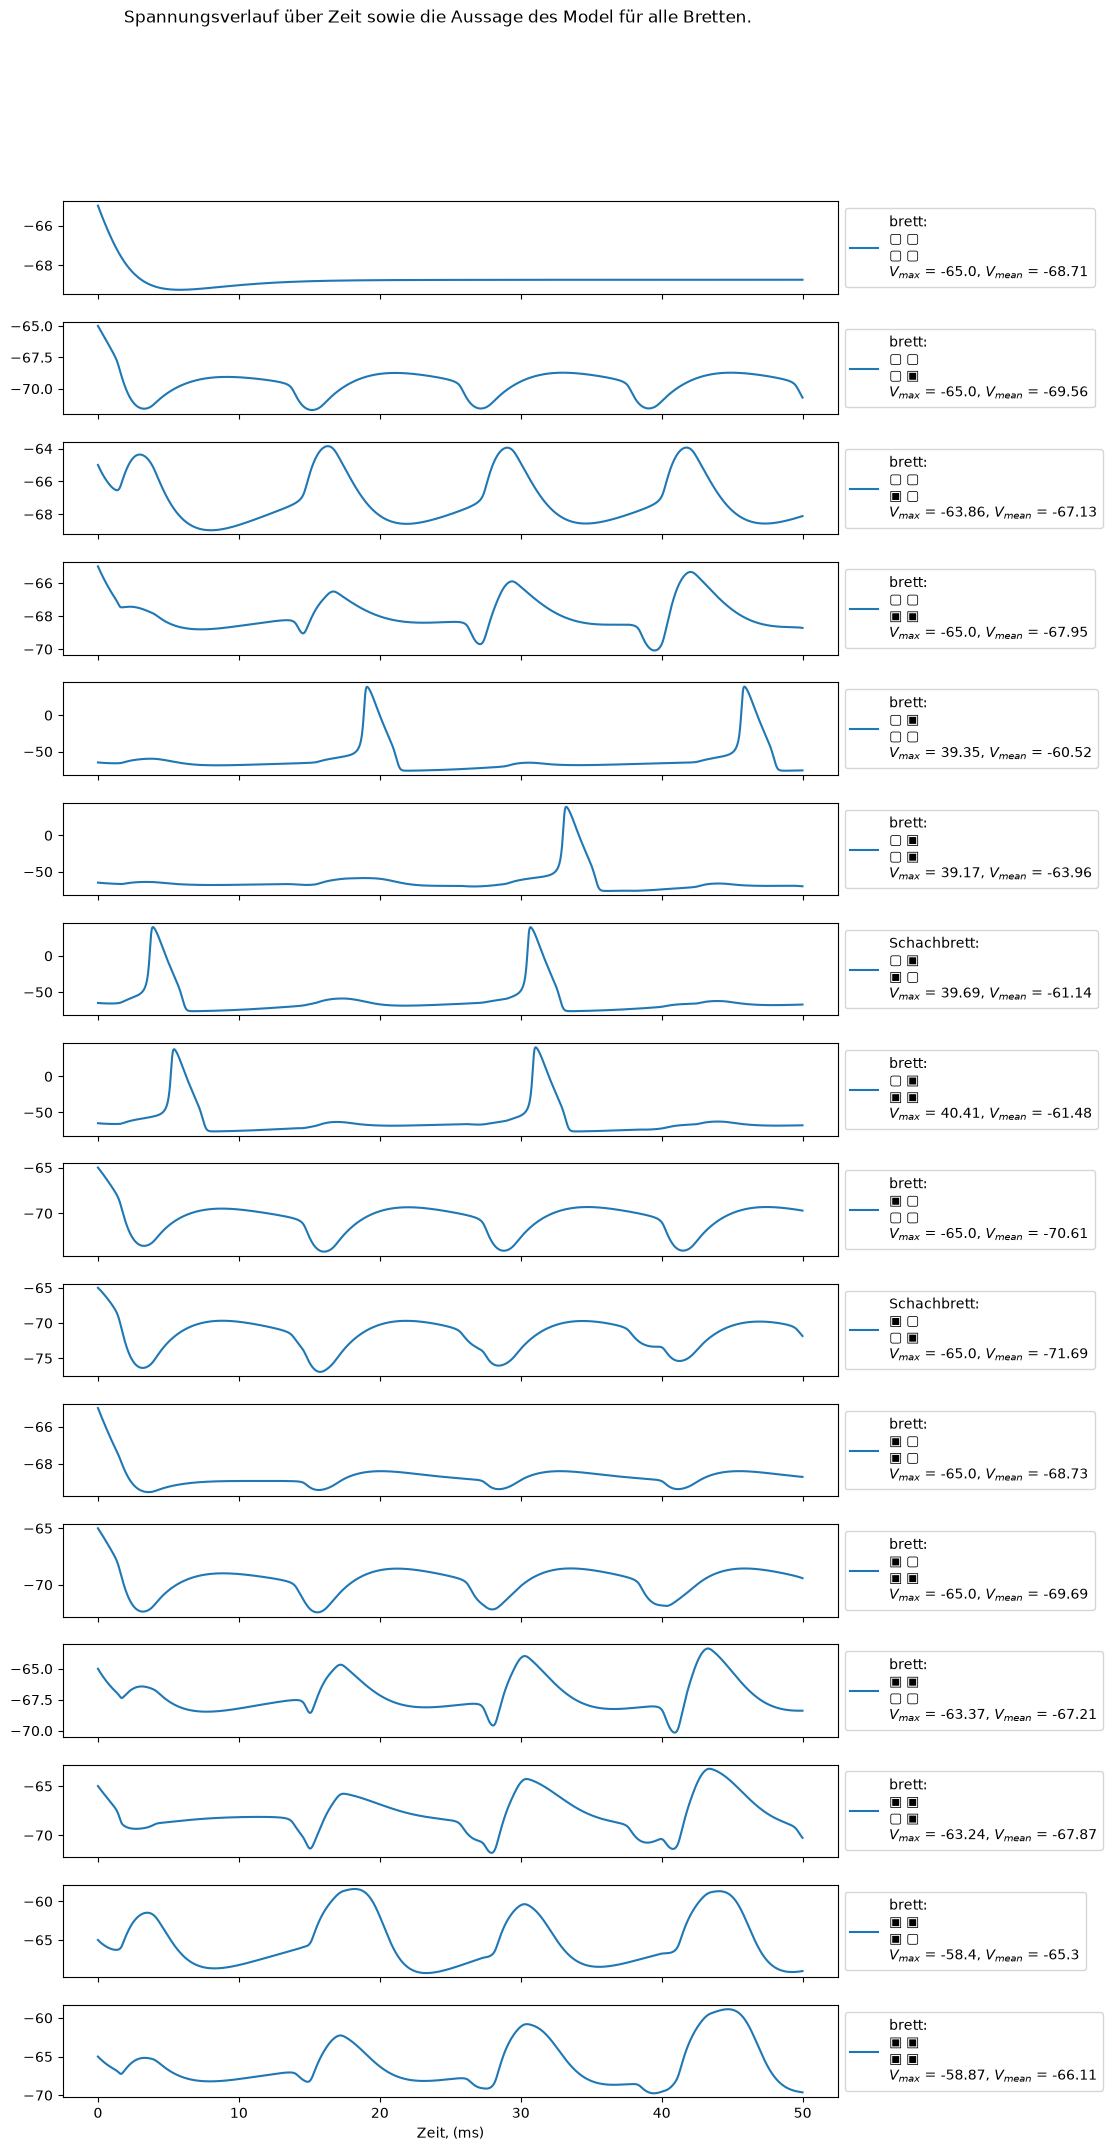

In [2]:
import numpy as np
from aufgabe3 import visualizer
visualizer.visualize_b2(np.array([0.03, -0.04, -0.05, 0.07,0.04, -0.03]))


**Aufgabe 3.c**
Mein Modell ist numerisch unstabil für Gewichtungen $w_{i,j} = 1, \text{für alle } i,j$. Unten können Sie den Code aufrufen, um diese zu sehen.

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1mFailed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1mNo implementation of function Function(<intrinsic _impl>) found for signature:
 
 >>> _impl(array(int64, 2d, C), array(float64, 1d, C))
 
There are 2 candidate implementations:
[1m - Of which 2 did not match due to:
 Intrinsic in function 'dot_2_impl.<locals>._impl': File: numba\np\linalg.py: Line 543.
   With argument(s): '(array(int64, 2d, C), array(float64, 1d, C))':[0m
[1m  Rejected as the implementation raised a specific error:
    TypingError: [1m'@' arguments must all have the same dtype[0m[0m
  raised from C:\Users\toima\PycharmProjects\Neuronensimulation\.venv\Lib\site-packages\numba\np\linalg.py:563
[0m
[0m[1mDuring: resolving callee type: Function(<intrinsic _impl>)[0m
[0m[1mDuring: typing of call at C:\Users\toima\PycharmProjects\Neuronensimulation\.venv\Lib\site-packages\numba\np\linalg.py (582)[0m
[1m
File

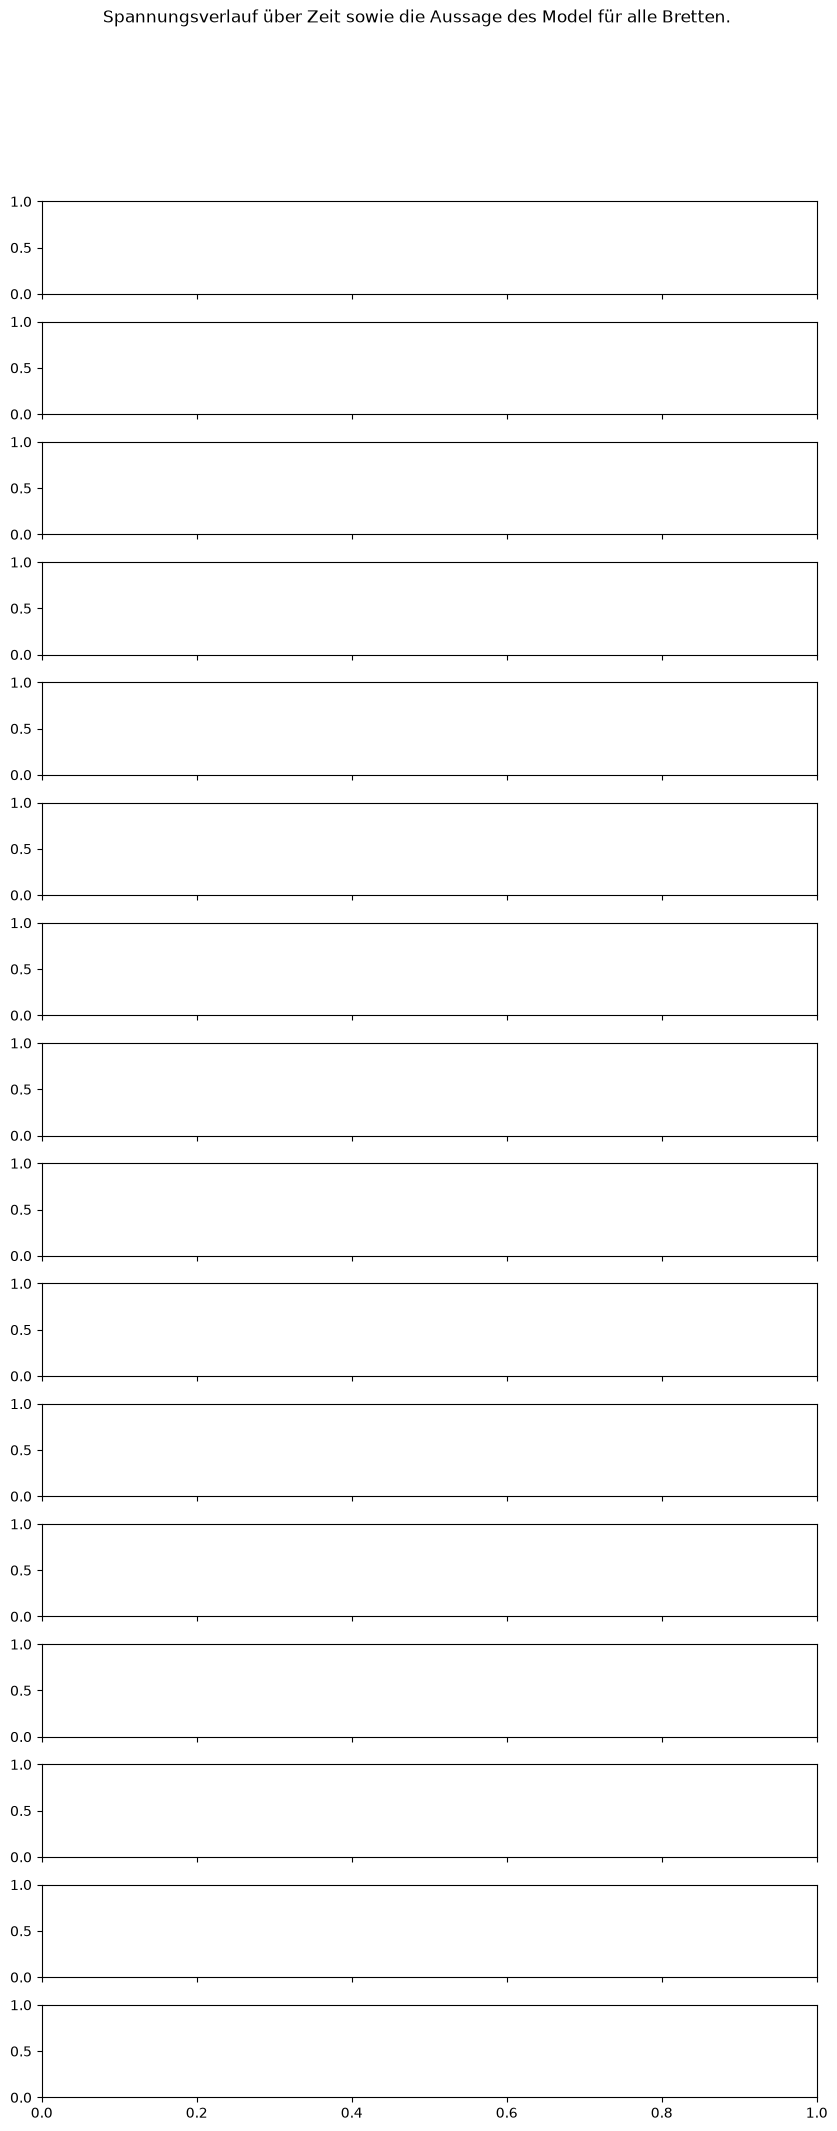

In [1]:
import numpy as np
from aufgabe3 import visualizer
visualizer.visualize_c([1, 1, 1, 1, 1, 1])

**Aufgabe 3.d**

Jetzt kommen zur Implementation des Lernalgorithmus. Den Code finden Sie in den Modulen "neural_network.py" und "learning_model".

Das Zweck der Klasse "Neural_Network" sind Speichern von Gewichtungen und Brettinput sowie Lösen der Gleichung (17) mithilfe vom Runge-Kutta-Methode für die Zustandsmatrix. Die Methode "get_deciding_neuron_voltage(self)" gibt uns 1D-ndarray, das den Verlauf der Spannung representiert.

Das Skript ""learning_model" verwendet die Klasse "Neural_Network" rür das Lernen (Wenn Sie selbst dieses Skript aufrufen möchten, ist es zu beachten, dass die Rechnungszeit groß sein kann). Das Ziel ist solche Parameter $\vec{w}$ zu finden, sodass die Spannung im letzten Neuron $V = 0$ beim Schachbrettinput überschreitet und für den rest im negativen Bereich blebt. Für das Problem wählen wir den Random-Walk-Algorithmus mit Loss-Function. <br>
Eine Loss-Function ist so definiert, dass diese für falsche Aussage einen positiven Wert gibt. In unserem Fall diese ist gegeben durch:
$$
\begin{cases}
    0 & \text{,wenn Schachbrett und } V_{\max} \ge 0 \\
    -V_{\max} & \text{,wenn Schachbrett und } V_{\max} < 0 \\
    0 & \text{,wenn kein Schachbrett und } V_{\max} < 0 \\
    V_{\max} & \text{,wenn kein Schachbrett und } \text{ and } V_{\max} \ge 0
\end{cases}
$$
Der Random-Walk-Algorithmus macht das Folgende:


Wählt zufällig Parametervektor $\vec{w}$ von dem Definitionsbereich, wo $|w_{i,j}| \leq 0.15$ aus der Unstabilität für größere Werte, <br>
Nachher wiederholt der Algorithmus mehrmals die nächsten Schritte: <br>
Misst mit der Loss-Function den Mittelwert des "Verlustes" für Schabretten. <br>
Misst mit der Loss-Function den Mittelwert des "Verlustes" für nicht Schabretten. <br>
Addiert diese 2 Werte. <br>
Wählt zufällig neuen Parametervektor $\vec{w'} = \vec{w} + \Delta \vec{w}$, der in dem Nahbereich von $\vec{w}$ liegt. <br>
Misst wieder den Verlust. <br>
Vergleicht mit dem alten Gesamtverlust. <br>
Falls der Verlust größer oder gleich als der alte, nimmt der Algorithmus den alten Wert für die Parameter, ansonsten lässt die neuen für die nächste Iteration.


Der Algorithmus kann einen Nachteil, dass die Ergebnisparameter in einem lokalen Minimumbereich liegen und wir können nicht uns sicher sein, dass diese ein das globale Maximum ist. Der Algorithmus ist abhängig von dem Anfangswert, den wir natürlich nicht kontrollieren können. In der unteren Zelle ist eine Menge der Ergebnisparameter verwendet, wo es nach dem Signal ausgesagt wird, ob es ein Schachbrett ist oder nein. Für diese Paramater werden beide Schachbretten und 11 von 14 der nicht Schachbretten erfolgreich erkannt.

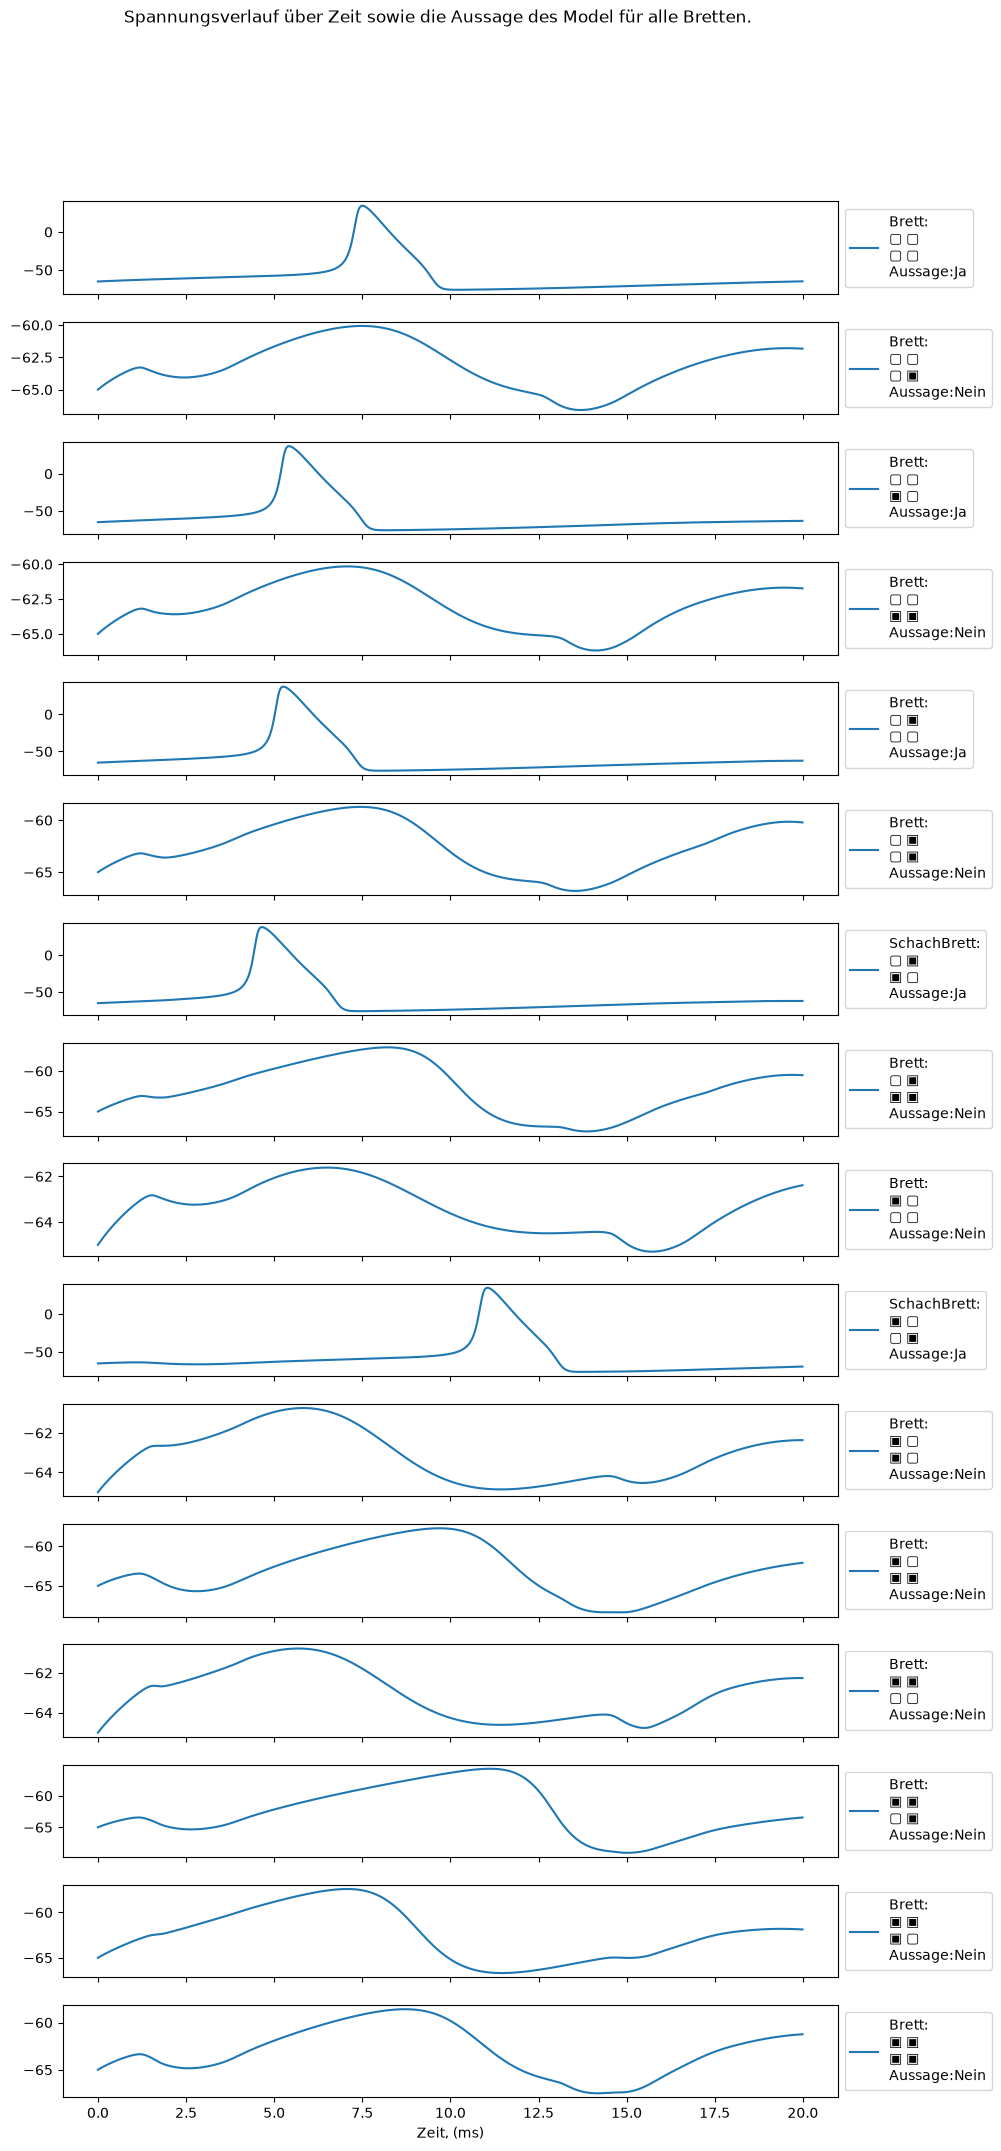

In [1]:
import numpy as np
from aufgabe3 import visualizer

optimal_weights = np.load("optimal_weights.npy")
visualizer.visualize_d(optimal_weights)

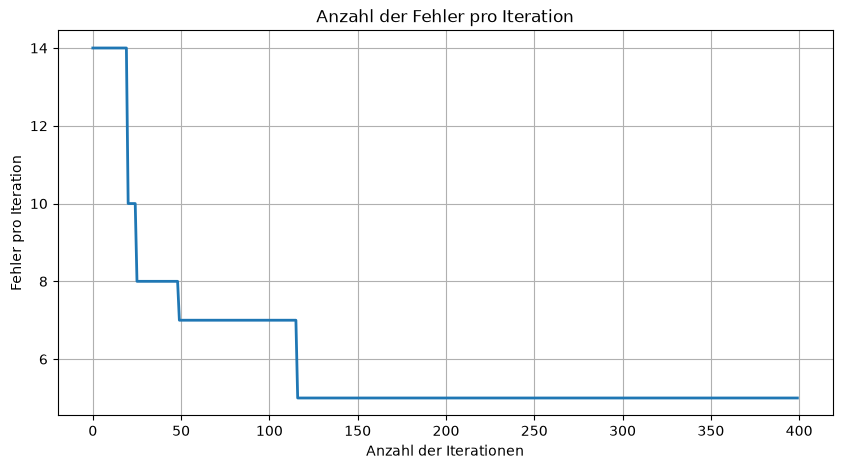

In [1]:
import numpy as np
from aufgabe3 import visualizer

visualizer.visualize_error_history(np.load("errors_history.npy"))